# Tugas 3 — Penerapan Word2Vec pada Data Teks Bahasa Indonesia

## Pencarian dan Penambangan Website

Notebook ini membahas penerapan Word2Vec dengan arsitektur **Skip-gram** pada data berita hasil scraping dari website Detik.

Tahapan yang dilakukan meliputi:

1. Memahami konsep Word2Vec, Skip-gram, dan CBOW.
2. Membentuk contoh pasangan kata target dan konteks.
3. Memuat dan memahami dataset berita hasil scraping.
4. Melakukan preprocessing teks dengan beberapa konfigurasi.
5. Membentuk embedding menggunakan Word2Vec Skip-gram.
6. Mengubah representasi kata menjadi representasi dokumen menggunakan mean pooling.
7. Melakukan hyperparameter tuning Word2Vec dan Gaussian Naive Bayes.
8. Membandingkan lima skenario preprocessing.
9. Melakukan pemodelan dan evaluasi menggunakan Gaussian Naive Bayes.
10. Menampilkan representasi vektor dokumen.
11. Menyimpan model Word2Vec dan model klasifikasi untuk digunakan kembali.

## 1. Perbandingan Arsitektur Word2Vec: Skip-gram dan CBOW

Word2Vec merupakan metode untuk mempelajari representasi kata dalam bentuk
vektor numerik berdasarkan pola konteks kata di dalam korpus.

Dua arsitektur utama Word2Vec adalah:

- **Skip-gram**: menggunakan satu kata target untuk memprediksi kata-kata
  konteks di sekitarnya.
- **CBOW (Continuous Bag of Words)**: menggunakan kata-kata konteks untuk
  memprediksi satu kata target.

Pada tugas ini digunakan arsitektur **Skip-gram** dengan parameter
`sg=1`.

In [1]:
import sys
import gensim

print("Python :", sys.version)
print("Gensim :", gensim.__version__)

Python : 3.12.3 (main, Aug 31 2026, 10:18:26) [GCC 13.3.0]
Gensim : 4.4.0


In [2]:
from gensim.models import Word2Vec

print("Word2Vec berhasil diimpor.")

Word2Vec berhasil diimpor.


## 2. Contoh Data Kalimat

Sebelum diterapkan pada dataset berita, Word2Vec diuji menggunakan contoh
kalimat sederhana yang telah ditokenisasi.

Setiap kalimat direpresentasikan sebagai list kata sehingga batas antar
kalimat tetap diketahui oleh model.

In [3]:
kalimat = [
    ["pemerintah", "menaikkan", "harga", "saham", "pasar", "keuangan"],
    ["investor", "membeli", "saham", "perusahaan", "teknologi", "pasar"],
    ["atlet", "meraih", "medali", "emas", "dalam", "kompetisi", "olahraga"]
]

n_vector = 10
window_size = 5

## 3. Melatih Word2Vec Skip-gram

Parameter yang digunakan:

- `vector_size=10` untuk menentukan jumlah dimensi vektor.
- `window=5` untuk menentukan ukuran konteks.
- `sg=1` untuk memilih arsitektur Skip-gram.
- `min_count=1` agar seluruh kata pada contoh dapat masuk vocabulary.
- `seed=42` agar proses lebih mudah direproduksi.

In [4]:
model_skipgram = Word2Vec(
    sentences=kalimat,
    vector_size=n_vector,
    window=window_size,
    sg=1,
    min_count=1,
    workers=1,
    seed=42
)

print("Model Word2Vec Skip-gram berhasil dilatih.")

Model Word2Vec Skip-gram berhasil dilatih.


## 4. Membentuk Pasangan Target dan Konteks

Pada Skip-gram, sebuah kata digunakan sebagai **target** dan kata-kata
di sekitarnya digunakan sebagai **konteks**.

Fungsi berikut digunakan untuk mengilustrasikan pembentukan pasangan
target-konteks berdasarkan ukuran window.

In [5]:
def ekstrak_kombinasi_skipgram(kalimat_list, window_size):
    pasangan_kombinasi = []

    for kalimat in kalimat_list:
        panjang_kalimat = len(kalimat)

        for i, kata_target in enumerate(kalimat):
            awal = max(0, i - window_size)
            akhir = min(panjang_kalimat, i + window_size + 1)

            for j in range(awal, akhir):
                if i != j:
                    kata_konteks = kalimat[j]
                    pasangan_kombinasi.append(
                        (kata_target, kata_konteks)
                    )

    return pasangan_kombinasi

In [6]:
semua_pasangan = ekstrak_kombinasi_skipgram(
    kalimat,
    window_size=window_size
)

kombinasi_unik = sorted(list(set(semua_pasangan)))

print(f"=== IDENTIFIKASI KOMBINASI KATA (window={window_size}) ===")
print(f"Total pasangan terbentuk : {len(semua_pasangan)}")
print(f"Total pasangan KATA UNIK : {len(kombinasi_unik)}\n")

print("Daftar Kombinasi Kata Unik (Target -> Konteks):")

for target, konteks in kombinasi_unik:
    print(f"Target: '{target}' --> Konteks: '{konteks}'")

=== IDENTIFIKASI KOMBINASI KATA (window=5) ===
Total pasangan terbentuk : 100
Total pasangan KATA UNIK : 98

Daftar Kombinasi Kata Unik (Target -> Konteks):
Target: 'atlet' --> Konteks: 'dalam'
Target: 'atlet' --> Konteks: 'emas'
Target: 'atlet' --> Konteks: 'kompetisi'
Target: 'atlet' --> Konteks: 'medali'
Target: 'atlet' --> Konteks: 'meraih'
Target: 'dalam' --> Konteks: 'atlet'
Target: 'dalam' --> Konteks: 'emas'
Target: 'dalam' --> Konteks: 'kompetisi'
Target: 'dalam' --> Konteks: 'medali'
Target: 'dalam' --> Konteks: 'meraih'
Target: 'dalam' --> Konteks: 'olahraga'
Target: 'emas' --> Konteks: 'atlet'
Target: 'emas' --> Konteks: 'dalam'
Target: 'emas' --> Konteks: 'kompetisi'
Target: 'emas' --> Konteks: 'medali'
Target: 'emas' --> Konteks: 'meraih'
Target: 'emas' --> Konteks: 'olahraga'
Target: 'harga' --> Konteks: 'keuangan'
Target: 'harga' --> Konteks: 'menaikkan'
Target: 'harga' --> Konteks: 'pasar'
Target: 'harga' --> Konteks: 'pemerintah'
Target: 'harga' --> Konteks: 'saham'
T

## 5. Representasi Vektor Kata

Setiap kata yang terdapat dalam vocabulary Word2Vec memiliki representasi
vektor numerik.

Vektor tersebut tidak memiliki arti yang dapat dibaca per dimensi secara
langsung. Makna representasi dilihat dari hubungan antar-vektor kata.

In [7]:
kata_uji = "saham"

vektor_kata = model_skipgram.wv[kata_uji]

print(f"=== HASIL SKIP-GRAM (n={n_vector}, window={window_size}) ===")
print(f"Ukuran dimensi vektor '{kata_uji}': {vektor_kata.shape[0]}")
print(f"Vektor angka untuk kata '{kata_uji}':\n{vektor_kata}")

=== HASIL SKIP-GRAM (n=10, window=5) ===
Ukuran dimensi vektor 'saham': 10
Vektor angka untuk kata 'saham':
[ 0.00530819  0.09512772  0.04711951  0.05224992  0.04349924  0.05722775
  0.00266594 -0.07442413  0.06794856 -0.00990942]


In [8]:
kata_uji = "saham"

vektor_kata = model_skipgram.wv[kata_uji]

print(f"=== HASIL SKIP-GRAM (n={n_vector}, window={window_size}) ===")
print(f"Ukuran dimensi vektor '{kata_uji}': {vektor_kata.shape[0]}")
print(f"Vektor angka untuk kata '{kata_uji}':\n{vektor_kata}")

=== HASIL SKIP-GRAM (n=10, window=5) ===
Ukuran dimensi vektor 'saham': 10
Vektor angka untuk kata 'saham':
[ 0.00530819  0.09512772  0.04711951  0.05224992  0.04349924  0.05722775
  0.00266594 -0.07442413  0.06794856 -0.00990942]


## 6. Skip-gram dan CBOW

Pada Gensim:

- `sg=1` digunakan untuk Skip-gram.
- `sg=0` digunakan untuk CBOW.

Perbedaan keduanya:

| Aspek | Skip-gram | CBOW |
|---|---|---|
| Input | Satu kata target | Kata-kata konteks |
| Prediksi | Kata-kata konteks | Satu kata target |
| Contoh | Dari `saham`, memprediksi `pasar` | Dari konteks, memprediksi `saham` |

Pada tugas ini hanya **Skip-gram yang digunakan sebagai eksperimen**.
CBOW digunakan sebagai pembanding konsep.

# 7. Persiapan Library

Library yang digunakan pada tahap berikutnya meliputi:

- Pandas untuk pengolahan dataset.
- NumPy untuk operasi numerik.
- Matplotlib dan Seaborn untuk visualisasi.
- WordCloud untuk eksplorasi kata.
- Sastrawi untuk stopword dan stemming bahasa Indonesia.
- tqdm untuk progress bar.
- Gensim untuk Word2Vec.
- Scikit-learn untuk pembagian data, Gaussian Naive Bayes, dan evaluasi.

In [9]:
%pip install -q Sastrawi wordcloud tqdm seaborn joblib

Note: you may need to restart the kernel to use updated packages.


In [10]:
from gensim.models import Word2Vec
import Sastrawi
import wordcloud
import tqdm
import seaborn
import joblib

print("Semua library Tugas 3 siap.")

Semua library Tugas 3 siap.


In [11]:
%pip install -q scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [73]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from tqdm.auto import tqdm
import logging
import joblib

from gensim.models import Word2Vec

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

tqdm.pandas()

# 8. Data Understanding

Dataset yang digunakan merupakan hasil scraping pada Tugas 1.

Dataset terdiri dari dua kategori berita:

- **Sport**
- **Finance**

Masing-masing dataset memiliki kolom kategori, URL, dan teks berita.

Kolom URL digunakan sebagai informasi sumber, tetapi tidak digunakan sebagai
fitur dalam pembentukan embedding.

In [13]:
df_sport = pd.read_csv("data/dataset_detik_sport.csv")
df_finance = pd.read_csv("data/dataset_detik_finance.csv")

df_all_ori = pd.concat(
    [df_sport, df_finance],
    ignore_index=True
)

print(df_all_ori)

    kategori                                                url  \
0      sport  https://sport.detik.com/sport-lain/d-8695603/e...   
1      sport  https://sport.detik.com/moto-gp/d-8695608/moto...   
2      sport  https://sport.detik.com/moto-gp/d-8695361/impi...   
3      sport  https://sport.detik.com/moto-gp/d-8695022/veda...   
4      sport  https://sport.detik.com/sport-lain/d-8694792/t...   
..       ...                                                ...   
195  finance  https://finance.detik.com/berita-ekonomi-bisni...   
196  finance  https://finance.detik.com/moneter/d-8693138/ut...   
197  finance  https://finance.detik.com/bursa-dan-valas/d-86...   
198  finance  https://finance.detik.com/berita-ekonomi-bisni...   
199  finance  https://finance.detik.com/berita-ekonomi-bisni...   

                                                  teks  
0    Menpora Erick Thohir senang kontingen Indonesi...  
1    Rangkaian seri balap MotoGP Jepang di Sirkuit ...  
2    Jorge Martin sedang

In [14]:
df_all = df_all_ori.drop("url", axis=1)

print(df_all)

    kategori                                               teks
0      sport  Menpora Erick Thohir senang kontingen Indonesi...
1      sport  Rangkaian seri balap MotoGP Jepang di Sirkuit ...
2      sport  Jorge Martin sedang memperjuangkan titel juara...
3      sport  Rider Indonesia Veda Ega Pratama balapan di Ma...
4      sport  Pelatih speed tim panjat tebing, Fitriyani, me...
..       ...                                                ...
195  finance  Kepala Badan Gizi Nasional (BGN) Sudaryono men...
196  finance  Utang pinjaman daring (pindar) masyarakat Indo...
197  finance  Jumlah investor pasar modal Indonesia terus be...
198  finance  Menteri Koordinator (Menko) Perekonomian Airla...
199  finance  Meski harga kedelai yang sepenuhnya hasil impo...

[200 rows x 2 columns]


In [15]:
print("Distribusi Kelas (Label) pada Dataset:")
print(df_all["kategori"].value_counts())

Distribusi Kelas (Label) pada Dataset:
kategori
sport      100
finance    100
Name: count, dtype: int64


In [16]:
print("Pengecekan data kosong (missing values):")
print(df_all.isnull().sum())

Pengecekan data kosong (missing values):
kategori    0
teks        0
dtype: int64


In [17]:
print("Mengecek panjang karakter pada setiap baris data:")
print(df_all["teks"].str.len())

Mengecek panjang karakter pada setiap baris data:
0      2004
1      1714
2      1538
3      1585
4      2747
       ... 
195    1997
196    2206
197    1699
198    1228
199    3413
Name: teks, Length: 200, dtype: int64


In [18]:
def visualisasi_panjang_kata(df, nama_kolom):
    df["jumlah_kata"] = df[nama_kolom].astype(str).apply(
        lambda x: len(x.split())
    )

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    sns.histplot(
        df["jumlah_kata"],
        bins=50,
        kde=True,
        ax=axes[0]
    )

    axes[0].set_title("Distribusi Panjang Kata per Dokumen")
    axes[0].set_xlabel("Jumlah Kata")
    axes[0].set_ylabel("Frekuensi")

    sns.boxplot(
        x=df["jumlah_kata"],
        ax=axes[1]
    )

    axes[1].set_title("Boxplot Panjang Kata")
    axes[1].set_xlabel("Jumlah Kata")

    plt.tight_layout()
    plt.show()

    print("=== Statistik Deskriptif Panjang Kata ===")
    display(df["jumlah_kata"].describe())

Menganalisis panjang kata untuk mendeteksi anomali...


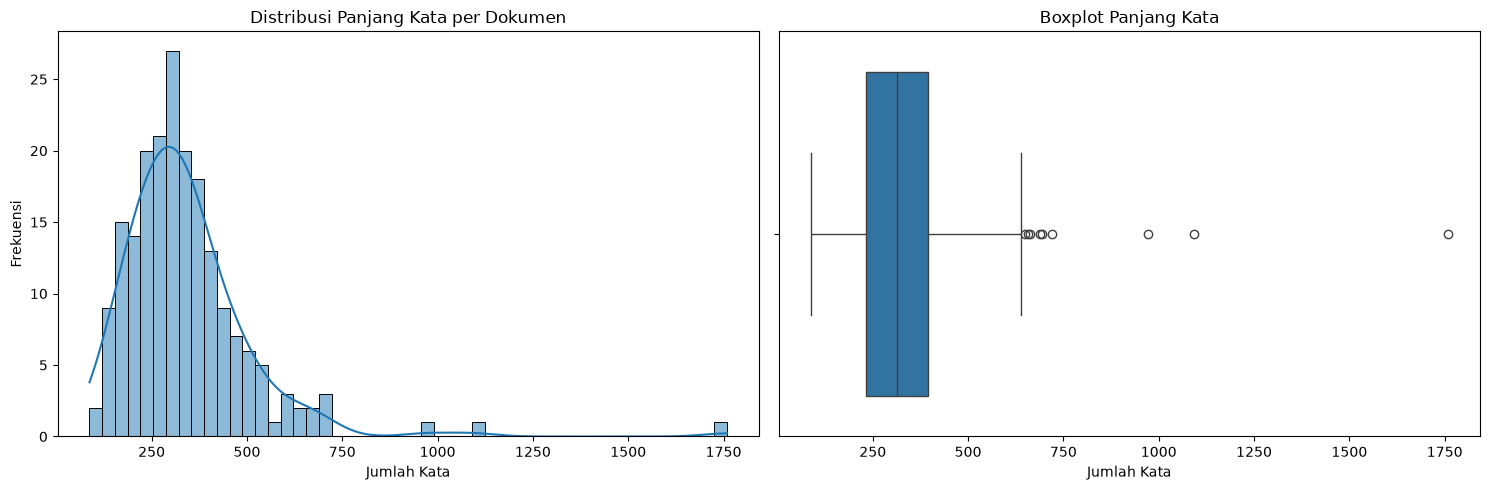

=== Statistik Deskriptif Panjang Kata ===


count     200.000000
mean      340.845000
std       176.210162
min        87.000000
25%       231.750000
50%       313.500000
75%       395.250000
max      1759.000000
Name: jumlah_kata, dtype: float64

In [19]:
print("Menganalisis panjang kata untuk mendeteksi anomali...")

visualisasi_panjang_kata(
    df_all,
    "teks"
)

In [20]:
def visualisasi_wordcloud(teks_series):
    factory = StopWordRemoverFactory()
    stopword_indo = set(factory.get_stop_words())

    semua_teks = " ".join(
        str(teks)
        for teks in teks_series
    )

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white",
        stopwords=stopword_indo,
        max_words=100
    ).generate(semua_teks)

    plt.figure(figsize=(12, 6))
    plt.imshow(
        wordcloud,
        interpolation="bilinear"
    )

    plt.axis("off")
    plt.title(
        "WordCloud Keseluruhan Dokumen Berita",
        fontsize=16,
        pad=20
    )

    plt.show()

Membuat WordCloud...


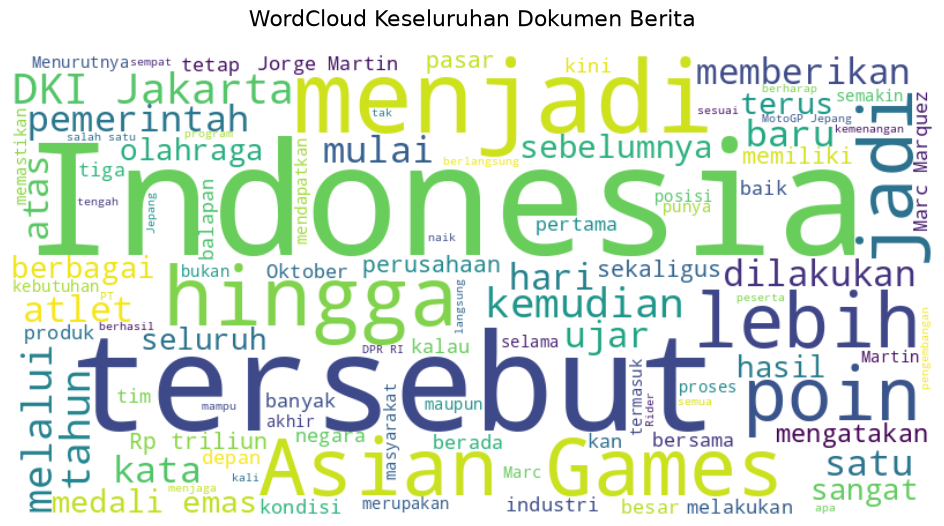

In [21]:
print("Membuat WordCloud...")

visualisasi_wordcloud(
    df_all["teks"]
)

In [22]:
def cari_kata(keyword, nama_kolom="teks"):
    hasil_pencarian = df_all[
        df_all[nama_kolom]
        .astype(str)
        .str.contains(
            keyword,
            case=False,
            na=False
        )
    ]

    print(
        f"Ditemukan {len(hasil_pencarian)} dokumen "
        f"yang mengandung kata '{keyword}'."
    )

    return hasil_pencarian[
        ["kategori", nama_kolom]
    ]

In [23]:
hasil = cari_kata("saham")

display(hasil.head())

Ditemukan 13 dokumen yang mengandung kata 'saham'.


,kategori,teks
72,sport,Ada banyak cara untuk ikut peduli menjaga kele...
104,finance,PT Bayan Resources Tbk (BYAN) mengubah perjanj...
110,finance,PT Danantara Investment Management (DIM) mengu...
120,finance,Elon Musk kembali menyandang status sebagai tr...
123,finance,Ajaib terus memperkuat layanan Saham Amerika u...


# 9. Data Preprocessing

Preprocessing dilakukan secara modular agar beberapa konfigurasi dapat
dibandingkan.

Tahapan utama preprocessing:

1. Case folding.
2. Menghapus tanda baca.
3. Menghapus atau mempertahankan angka.
4. Tokenisasi.
5. Menghapus atau mempertahankan stopword.
6. Mengaktifkan atau menonaktifkan stemming.

Lima skenario preprocessing akan digunakan dalam eksperimen.

In [24]:
daftar_stopword = set(
    StopWordRemoverFactory().get_stop_words()
)

stemmer = StemmerFactory().create_stemmer()

tqdm.pandas()

In [25]:
def preprocess_modular(
    teks,
    hapus_angka=True,
    hapus_stopword=True,
    pakai_stemming=True
):
    teks = str(teks).lower()

    teks = re.sub(
        r"[^\w\s]",
        " ",
        teks
    )

    if hapus_angka:
        teks = re.sub(
            r"\d+",
            "",
            teks
        )

    tokens = teks.split()

    if hapus_stopword:
        tokens = [
            w for w in tokens
            if w not in daftar_stopword
        ]

    if pakai_stemming:
        teks_gabung = " ".join(tokens)

        teks_stem = stemmer.stem(
            teks_gabung
        )

        tokens = teks_stem.split()

    return tokens

## 10. Lima Skenario Preprocessing

Eksperimen menggunakan lima konfigurasi berikut:

| Skenario | Angka | Stopword | Stemming |
|---|---|---|---|
| Skenario 1 | Dihapus | Dihapus | Aktif |
| Skenario 2 | Dipertahankan | Dihapus | Aktif |
| Skenario 3 | Dihapus | Dipertahankan | Aktif |
| Skenario 4 | Dihapus | Dihapus | Tidak aktif |
| Skenario 5 | Dipertahankan | Dipertahankan | Aktif |

Setiap skenario akan digunakan sebagai input Word2Vec dan Gaussian Naive Bayes.

# 11. Pelatihan Word2Vec Skip-gram

Word2Vec digunakan untuk mempelajari representasi vektor dari setiap kata.

Arsitektur yang digunakan adalah Skip-gram dengan:

- `sg=1`
- `min_count=1`
- `seed=42`

Parameter `vector_size` dan `window` akan dituning pada tahap berikutnya.

In [26]:
def latih_skipgram(
    list_of_tokens,
    ukuran_vektor=50,
    ukuran_window=2
):
    model = Word2Vec(
        sentences=list_of_tokens,
        vector_size=ukuran_vektor,
        window=ukuran_window,
        sg=1,
        min_count=1,
        workers=4,
        seed=42
    )

    return model

In [27]:
def get_vektor_rata_rata(tokens, model):
    vektor_kata = [
        model.wv[kata]
        for kata in tokens
        if kata in model.wv
    ]

    if not vektor_kata:
        return np.zeros(
            model.vector_size
        )

    return np.mean(
        vektor_kata,
        axis=0
    )

# 12. Hyperparameter Tuning

Tiga parameter akan diuji:

### Word2Vec

- `vector_size`: 50, 75, 100
- `window`: 3, 5, 7

### Gaussian Naive Bayes

- `var_smoothing`: 1e-9, 1e-5, 1e-1

Dengan tiga pilihan pada masing-masing parameter, terdapat:

**3 × 3 × 3 = 27 kombinasi**

untuk setiap skenario preprocessing.

In [28]:
def tuning_w2v_naive_bayes(
    tokens_series,
    target_series,
    list_vektor,
    list_window,
    list_smoothing
):
    hasil = []

    logging.getLogger().setLevel(
        logging.WARNING
    )

    for v in list_vektor:
        for w in list_window:

            print(
                f"Melatih Skip-gram "
                f"(Vektor={v}, Window={w})..."
            )

            model_w2v = latih_skipgram(
                tokens_series,
                ukuran_vektor=v,
                ukuran_window=w
            )

            fitur_X = tokens_series.apply(
                lambda x: get_vektor_rata_rata(
                    x,
                    model_w2v
                )
            )

            X_df = pd.DataFrame(
                fitur_X.tolist()
            )

            X_train, X_test, y_train, y_test = train_test_split(
                X_df,
                target_series,
                test_size=0.2,
                random_state=42,
                stratify=target_series
            )

            for smooth in list_smoothing:

                nb = GaussianNB(
                    var_smoothing=smooth
                )

                nb.fit(
                    X_train,
                    y_train
                )

                y_pred = nb.predict(
                    X_test
                )

                akurasi = accuracy_score(
                    y_test,
                    y_pred
                )

                hasil.append({
                    "Vector_Size": v,
                    "Window": w,
                    "Var_Smoothing": smooth,
                    "Akurasi": akurasi
                })

    return (
        pd.DataFrame(hasil)
        .sort_values(
            by="Akurasi",
            ascending=False
        )
        .reset_index(drop=True)
    )

# 13. Skenario 1 — Angka Dihapus

Konfigurasi:

- Angka: dihapus
- Stopword: dihapus
- Stemming: aktif

In [29]:
print(
    "1. Memulai Preprocessing Skenario 1..."
)

df_all["token_skenario_1"] = (
    df_all["teks"]
    .progress_apply(
        lambda x: preprocess_modular(
            x,
            hapus_angka=True,
            hapus_stopword=True,
            pakai_stemming=True
        )
    )
)

1. Memulai Preprocessing Skenario 1...


100%|███| 200/200 [05:07<00:00,  1.54s/it]


In [30]:
print(
    "Memulai Hyperparameter Tuning Skenario 1..."
)

hasil_tuning_skenario_1 = tuning_w2v_naive_bayes(
    tokens_series=df_all["token_skenario_1"],
    target_series=df_all["kategori"],
    list_vektor=[50, 75, 100],
    list_window=[3, 5, 7],
    list_smoothing=[1e-9, 1e-5, 1e-1]
)

print("\n=== TOP 5 HASIL KOMBINASI TERBAIK ===")

display(
    hasil_tuning_skenario_1.head()
)

Memulai Hyperparameter Tuning Skenario 1...
Melatih Skip-gram (Vektor=50, Window=3)...
Melatih Skip-gram (Vektor=50, Window=5)...
Melatih Skip-gram (Vektor=50, Window=7)...
Melatih Skip-gram (Vektor=75, Window=3)...
Melatih Skip-gram (Vektor=75, Window=5)...
Melatih Skip-gram (Vektor=75, Window=7)...
Melatih Skip-gram (Vektor=100, Window=3)...
Melatih Skip-gram (Vektor=100, Window=5)...
Melatih Skip-gram (Vektor=100, Window=7)...

=== TOP 5 HASIL KOMBINASI TERBAIK ===


,Vector_Size,Window,Var_Smoothing,Akurasi
0,50,3,1.000000e-09,0.9
1,50,3,1.000000e-05,0.9
2,50,5,1.000000e-09,0.9
3,75,3,1.000000e-05,0.9
4,50,5,1.000000e-05,0.9


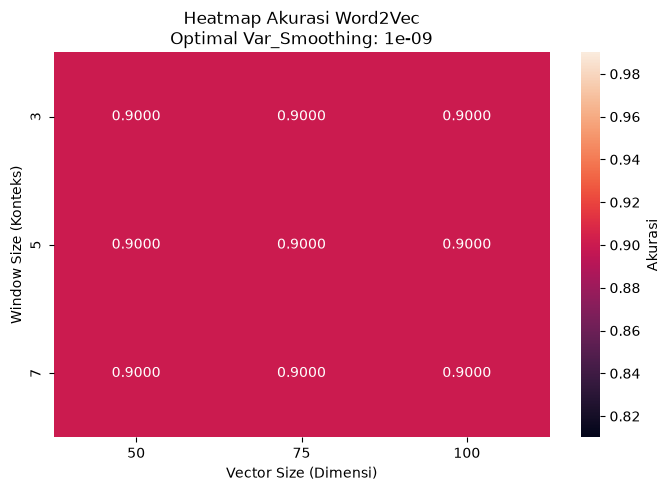

In [31]:
best_smooth = (
    hasil_tuning_skenario_1[
        "Var_Smoothing"
    ].iloc[0]
)

df_heatmap = (
    hasil_tuning_skenario_1[
        hasil_tuning_skenario_1[
            "Var_Smoothing"
        ] == best_smooth
    ]
)

pivot_table = df_heatmap.pivot(
    index="Window",
    columns="Vector_Size",
    values="Akurasi"
)

plt.figure(
    figsize=(8, 5)
)

sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".4f",
    cbar_kws={
        "label": "Akurasi"
    }
)

plt.title(
    f"Heatmap Akurasi Word2Vec\n"
    f"Optimal Var_Smoothing: {best_smooth}"
)

plt.xlabel(
    "Vector Size (Dimensi)"
)

plt.ylabel(
    "Window Size (Konteks)"
)

plt.show()

# 14. Skenario 2 — Angka Dipertahankan

Konfigurasi:

- Angka: dipertahankan
- Stopword: dihapus
- Stemming: aktif

In [32]:
print(
    "2. Memulai Preprocessing Skenario 2..."
)

df_all["token_skenario_2"] = (
    df_all["teks"]
    .progress_apply(
        lambda x: preprocess_modular(
            x,
            hapus_angka=False,
            hapus_stopword=True,
            pakai_stemming=True
        )
    )
)

2. Memulai Preprocessing Skenario 2...


100%|███| 200/200 [00:25<00:00,  7.92it/s]


In [33]:
print(
    "Memulai Hyperparameter Tuning Skenario 2..."
)

hasil_tuning_skenario_2 = tuning_w2v_naive_bayes(
    tokens_series=df_all["token_skenario_2"],
    target_series=df_all["kategori"],
    list_vektor=[50, 75, 100],
    list_window=[3, 5, 7],
    list_smoothing=[1e-9, 1e-5, 1e-1]
)

print("\n=== TOP 5 HASIL KOMBINASI TERBAIK ===")

display(
    hasil_tuning_skenario_2.head()
)

Memulai Hyperparameter Tuning Skenario 2...
Melatih Skip-gram (Vektor=50, Window=3)...
Melatih Skip-gram (Vektor=50, Window=5)...
Melatih Skip-gram (Vektor=50, Window=7)...
Melatih Skip-gram (Vektor=75, Window=3)...
Melatih Skip-gram (Vektor=75, Window=5)...
Melatih Skip-gram (Vektor=75, Window=7)...
Melatih Skip-gram (Vektor=100, Window=3)...
Melatih Skip-gram (Vektor=100, Window=5)...
Melatih Skip-gram (Vektor=100, Window=7)...

=== TOP 5 HASIL KOMBINASI TERBAIK ===


,Vector_Size,Window,Var_Smoothing,Akurasi
0,50,7,1.000000e-09,0.925
1,50,7,1.000000e-05,0.925
2,75,7,1.000000e-05,0.925
3,100,7,1.000000e-05,0.925
4,100,7,1.000000e-09,0.925


# 15. Skenario 3 — Stopword Dipertahankan

Konfigurasi:

- Angka: dihapus
- Stopword: dipertahankan
- Stemming: aktif

In [34]:
print(
    "3. Memulai Preprocessing Skenario 3..."
)

df_all["token_skenario_3"] = (
    df_all["teks"]
    .progress_apply(
        lambda x: preprocess_modular(
            x,
            hapus_angka=True,
            hapus_stopword=False,
            pakai_stemming=True
        )
    )
)

3. Memulai Preprocessing Skenario 3...


100%|██| 200/200 [00:00<00:00, 446.67it/s]


In [35]:
print(
    "Memulai Hyperparameter Tuning Skenario 3..."
)

hasil_tuning_skenario_3 = tuning_w2v_naive_bayes(
    tokens_series=df_all["token_skenario_3"],
    target_series=df_all["kategori"],
    list_vektor=[50, 75, 100],
    list_window=[3, 5, 7],
    list_smoothing=[1e-9, 1e-5, 1e-1]
)

print("\n=== TOP 5 HASIL KOMBINASI TERBAIK ===")

display(
    hasil_tuning_skenario_3.head()
)

Memulai Hyperparameter Tuning Skenario 3...
Melatih Skip-gram (Vektor=50, Window=3)...
Melatih Skip-gram (Vektor=50, Window=5)...
Melatih Skip-gram (Vektor=50, Window=7)...
Melatih Skip-gram (Vektor=75, Window=3)...
Melatih Skip-gram (Vektor=75, Window=5)...
Melatih Skip-gram (Vektor=75, Window=7)...
Melatih Skip-gram (Vektor=100, Window=3)...
Melatih Skip-gram (Vektor=100, Window=5)...
Melatih Skip-gram (Vektor=100, Window=7)...

=== TOP 5 HASIL KOMBINASI TERBAIK ===


,Vector_Size,Window,Var_Smoothing,Akurasi
0,100,5,1.000000e-09,0.900
1,100,5,1.000000e-05,0.900
2,50,3,1.000000e-09,0.875
3,75,3,1.000000e-05,0.875
4,50,5,1.000000e-05,0.875


# 16. Skenario 4 — Stemming Tidak Digunakan

Konfigurasi:

- Angka: dihapus
- Stopword: dihapus
- Stemming: tidak aktif

In [36]:
print(
    "4. Memulai Preprocessing Skenario 4..."
)

df_all["token_skenario_4"] = (
    df_all["teks"]
    .progress_apply(
        lambda x: preprocess_modular(
            x,
            hapus_angka=True,
            hapus_stopword=True,
            pakai_stemming=False
        )
    )
)

4. Memulai Preprocessing Skenario 4...


100%|█| 200/200 [00:00<00:00, 6572.60it/s]


In [37]:
print(
    "Memulai Hyperparameter Tuning Skenario 4..."
)

hasil_tuning_skenario_4 = tuning_w2v_naive_bayes(
    tokens_series=df_all["token_skenario_4"],
    target_series=df_all["kategori"],
    list_vektor=[50, 75, 100],
    list_window=[3, 5, 7],
    list_smoothing=[1e-9, 1e-5, 1e-1]
)

print("\n=== TOP 5 HASIL KOMBINASI TERBAIK ===")

display(
    hasil_tuning_skenario_4.head()
)

Memulai Hyperparameter Tuning Skenario 4...
Melatih Skip-gram (Vektor=50, Window=3)...
Melatih Skip-gram (Vektor=50, Window=5)...
Melatih Skip-gram (Vektor=50, Window=7)...
Melatih Skip-gram (Vektor=75, Window=3)...
Melatih Skip-gram (Vektor=75, Window=5)...
Melatih Skip-gram (Vektor=75, Window=7)...
Melatih Skip-gram (Vektor=100, Window=3)...
Melatih Skip-gram (Vektor=100, Window=5)...
Melatih Skip-gram (Vektor=100, Window=7)...

=== TOP 5 HASIL KOMBINASI TERBAIK ===


,Vector_Size,Window,Var_Smoothing,Akurasi
0,50,3,1.000000e-09,0.9
1,50,3,1.000000e-05,0.9
2,50,5,1.000000e-09,0.9
3,75,3,1.000000e-05,0.9
4,50,5,1.000000e-05,0.9


# 17. Skenario 5 — Angka dan Stopword Dipertahankan

Konfigurasi:

- Angka: dipertahankan
- Stopword: dipertahankan
- Stemming: aktif

In [38]:
print(
    "5. Memulai Preprocessing Skenario 5..."
)

df_all["token_skenario_5"] = (
    df_all["teks"]
    .progress_apply(
        lambda x: preprocess_modular(
            x,
            hapus_angka=False,
            hapus_stopword=False,
            pakai_stemming=True
        )
    )
)

5. Memulai Preprocessing Skenario 5...


100%|█| 200/200 [00:00<00:00, 1905.24it/s]


In [39]:
print(
    "Memulai Hyperparameter Tuning Skenario 5..."
)

hasil_tuning_skenario_5 = tuning_w2v_naive_bayes(
    tokens_series=df_all["token_skenario_5"],
    target_series=df_all["kategori"],
    list_vektor=[50, 75, 100],
    list_window=[3, 5, 7],
    list_smoothing=[1e-9, 1e-5, 1e-1]
)

print("\n=== TOP 5 HASIL KOMBINASI TERBAIK ===")

display(
    hasil_tuning_skenario_5.head()
)

Memulai Hyperparameter Tuning Skenario 5...
Melatih Skip-gram (Vektor=50, Window=3)...
Melatih Skip-gram (Vektor=50, Window=5)...
Melatih Skip-gram (Vektor=50, Window=7)...
Melatih Skip-gram (Vektor=75, Window=3)...
Melatih Skip-gram (Vektor=75, Window=5)...
Melatih Skip-gram (Vektor=75, Window=7)...
Melatih Skip-gram (Vektor=100, Window=3)...
Melatih Skip-gram (Vektor=100, Window=5)...
Melatih Skip-gram (Vektor=100, Window=7)...

=== TOP 5 HASIL KOMBINASI TERBAIK ===


,Vector_Size,Window,Var_Smoothing,Akurasi
0,75,3,1.000000e-09,0.875
1,50,5,1.000000e-05,0.875
2,50,5,1.000000e-09,0.875
3,75,3,1.000000e-05,0.875
4,75,5,1.000000e-01,0.875


# 18. Modeling Final Skenario 1

Parameter terbaik diambil dari hasil hyperparameter tuning Skenario 1.

Parameter tersebut kemudian digunakan untuk:

1. Melatih ulang Word2Vec.
2. Membentuk mean pooling.
3. Membagi data menjadi data latih dan data uji.
4. Melatih Gaussian Naive Bayes.
5. Menghasilkan prediksi.
6. Mengevaluasi model menggunakan accuracy, precision, recall, F1-score,
   dan confusion matrix.

In [40]:
best_v1 = int(
    hasil_tuning_skenario_1[
        "Vector_Size"
    ].iloc[0]
)

best_w1 = int(
    hasil_tuning_skenario_1[
        "Window"
    ].iloc[0]
)

best_s1 = float(
    hasil_tuning_skenario_1[
        "Var_Smoothing"
    ].iloc[0]
)

print(
    "Menggunakan Parameter -> "
    f"Vector: {best_v1}, "
    f"Window: {best_w1}, "
    f"Smoothing: {best_s1}"
)

Menggunakan Parameter -> Vector: 50, Window: 3, Smoothing: 1e-09


In [41]:
model_w2v_final_s1 = latih_skipgram(
    df_all["token_skenario_1"],
    ukuran_vektor=best_v1,
    ukuran_window=best_w1
)

fitur_X_final_s1 = (
    df_all["token_skenario_1"]
    .apply(
        lambda x: get_vektor_rata_rata(
            x,
            model_w2v_final_s1
        )
    )
)

X_df_final_s1 = pd.DataFrame(
    fitur_X_final_s1.tolist()
)

y_df_final_s1 = df_all["kategori"]

In [42]:
X_train_s1, X_test_s1, y_train_s1, y_test_s1 = train_test_split(
    X_df_final_s1,
    y_df_final_s1,
    test_size=0.2,
    random_state=42,
    stratify=y_df_final_s1
)

nb_final_s1 = GaussianNB(
    var_smoothing=best_s1
)

nb_final_s1.fit(
    X_train_s1,
    y_train_s1
)

y_pred_s1 = nb_final_s1.predict(
    X_test_s1
)

LAPORAN KLASIFIKASI SKENARIO 1:
Akurasi Model : 87.50%

              precision    recall  f1-score   support

     finance       0.83      0.95      0.88        20
       sport       0.94      0.80      0.86        20

    accuracy                           0.88        40
   macro avg       0.88      0.88      0.87        40
weighted avg       0.88      0.88      0.87        40



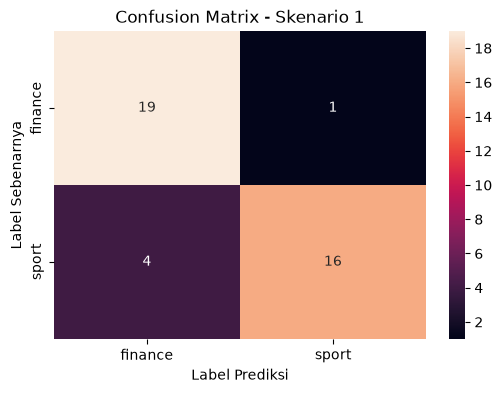

In [43]:
print("LAPORAN KLASIFIKASI SKENARIO 1:")

print(
    f"Akurasi Model : "
    f"{accuracy_score(y_test_s1, y_pred_s1) * 100:.2f}%\n"
)

print(
    classification_report(
        y_test_s1,
        y_pred_s1
    )
)

cm1 = confusion_matrix(
    y_test_s1,
    y_pred_s1
)

plt.figure(
    figsize=(6, 4)
)

sns.heatmap(
    cm1,
    annot=True,
    fmt="d",
    xticklabels=nb_final_s1.classes_,
    yticklabels=nb_final_s1.classes_
)

plt.title(
    "Confusion Matrix - Skenario 1"
)

plt.ylabel(
    "Label Sebenarnya"
)

plt.xlabel(
    "Label Prediksi"
)

plt.show()

# 19. Modeling Final Skenario 2

In [44]:
best_v2 = int(
    hasil_tuning_skenario_2[
        "Vector_Size"
    ].iloc[0]
)

best_w2 = int(
    hasil_tuning_skenario_2[
        "Window"
    ].iloc[0]
)

best_s2 = float(
    hasil_tuning_skenario_2[
        "Var_Smoothing"
    ].iloc[0]
)

print(
    "Menggunakan Parameter -> "
    f"Vector: {best_v2}, "
    f"Window: {best_w2}, "
    f"Smoothing: {best_s2}"
)

Menggunakan Parameter -> Vector: 50, Window: 7, Smoothing: 1e-09


In [45]:
model_w2v_final_s2 = latih_skipgram(
    df_all["token_skenario_2"],
    ukuran_vektor=best_v2,
    ukuran_window=best_w2
)

fitur_X_final_s2 = (
    df_all["token_skenario_2"]
    .apply(
        lambda x: get_vektor_rata_rata(
            x,
            model_w2v_final_s2
        )
    )
)

X_df_final_s2 = pd.DataFrame(
    fitur_X_final_s2.tolist()
)

y_df_final_s2 = df_all["kategori"]

In [46]:
X_train_s2, X_test_s2, y_train_s2, y_test_s2 = train_test_split(
    X_df_final_s2,
    y_df_final_s2,
    test_size=0.2,
    random_state=42,
    stratify=y_df_final_s2
)

nb_final_s2 = GaussianNB(
    var_smoothing=best_s2
)

nb_final_s2.fit(
    X_train_s2,
    y_train_s2
)

y_pred_s2 = nb_final_s2.predict(
    X_test_s2
)

LAPORAN KLASIFIKASI SKENARIO 2:
Akurasi Model : 92.50%

              precision    recall  f1-score   support

     finance       0.90      0.95      0.93        20
       sport       0.95      0.90      0.92        20

    accuracy                           0.93        40
   macro avg       0.93      0.93      0.92        40
weighted avg       0.93      0.93      0.92        40



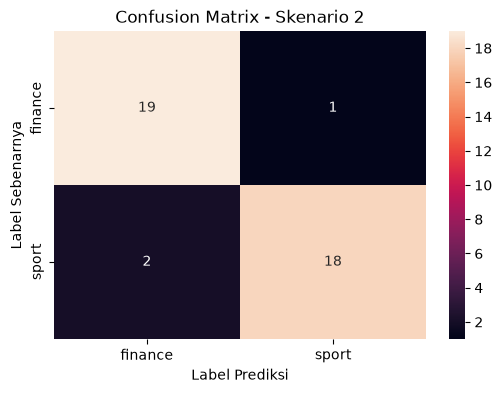

In [47]:
print("LAPORAN KLASIFIKASI SKENARIO 2:")

print(
    f"Akurasi Model : "
    f"{accuracy_score(y_test_s2, y_pred_s2) * 100:.2f}%\n"
)

print(
    classification_report(
        y_test_s2,
        y_pred_s2
    )
)

cm2 = confusion_matrix(
    y_test_s2,
    y_pred_s2
)

plt.figure(
    figsize=(6, 4)
)

sns.heatmap(
    cm2,
    annot=True,
    fmt="d",
    xticklabels=nb_final_s2.classes_,
    yticklabels=nb_final_s2.classes_
)

plt.title(
    "Confusion Matrix - Skenario 2"
)

plt.ylabel(
    "Label Sebenarnya"
)

plt.xlabel(
    "Label Prediksi"
)

plt.show()

# 20. Modeling Final Skenario 3

In [48]:
best_v3 = int(
    hasil_tuning_skenario_3[
        "Vector_Size"
    ].iloc[0]
)

best_w3 = int(
    hasil_tuning_skenario_3[
        "Window"
    ].iloc[0]
)

best_s3 = float(
    hasil_tuning_skenario_3[
        "Var_Smoothing"
    ].iloc[0]
)

print(
    "Menggunakan Parameter -> "
    f"Vector: {best_v3}, "
    f"Window: {best_w3}, "
    f"Smoothing: {best_s3}"
)

Menggunakan Parameter -> Vector: 100, Window: 5, Smoothing: 1e-09


In [49]:
model_w2v_final_s3 = latih_skipgram(
    df_all["token_skenario_3"],
    ukuran_vektor=best_v3,
    ukuran_window=best_w3
)

fitur_X_final_s3 = (
    df_all["token_skenario_3"]
    .apply(
        lambda x: get_vektor_rata_rata(
            x,
            model_w2v_final_s3
        )
    )
)

X_df_final_s3 = pd.DataFrame(
    fitur_X_final_s3.tolist()
)

y_df_final_s3 = df_all["kategori"]

In [50]:
X_train_s3, X_test_s3, y_train_s3, y_test_s3 = train_test_split(
    X_df_final_s3,
    y_df_final_s3,
    test_size=0.2,
    random_state=42,
    stratify=y_df_final_s3
)

nb_final_s3 = GaussianNB(
    var_smoothing=best_s3
)

nb_final_s3.fit(
    X_train_s3,
    y_train_s3
)

y_pred_s3 = nb_final_s3.predict(
    X_test_s3
)

LAPORAN KLASIFIKASI SKENARIO 3:
Akurasi Model : 87.50%

              precision    recall  f1-score   support

     finance       0.83      0.95      0.88        20
       sport       0.94      0.80      0.86        20

    accuracy                           0.88        40
   macro avg       0.88      0.88      0.87        40
weighted avg       0.88      0.88      0.87        40



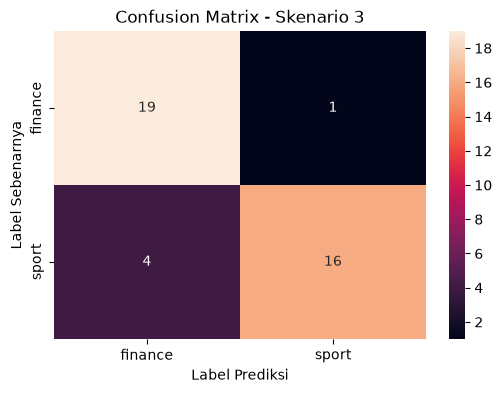

In [51]:
print("LAPORAN KLASIFIKASI SKENARIO 3:")

print(
    f"Akurasi Model : "
    f"{accuracy_score(y_test_s3, y_pred_s3) * 100:.2f}%\n"
)

print(
    classification_report(
        y_test_s3,
        y_pred_s3
    )
)

cm3 = confusion_matrix(
    y_test_s3,
    y_pred_s3
)

plt.figure(
    figsize=(6, 4)
)

sns.heatmap(
    cm3,
    annot=True,
    fmt="d",
    xticklabels=nb_final_s3.classes_,
    yticklabels=nb_final_s3.classes_
)

plt.title(
    "Confusion Matrix - Skenario 3"
)

plt.ylabel(
    "Label Sebenarnya"
)

plt.xlabel(
    "Label Prediksi"
)

plt.show()

# 21. Modeling Final Skenario 4

In [52]:
best_v4 = int(
    hasil_tuning_skenario_4[
        "Vector_Size"
    ].iloc[0]
)

best_w4 = int(
    hasil_tuning_skenario_4[
        "Window"
    ].iloc[0]
)

best_s4 = float(
    hasil_tuning_skenario_4[
        "Var_Smoothing"
    ].iloc[0]
)

print(
    "Menggunakan Parameter -> "
    f"Vector: {best_v4}, "
    f"Window: {best_w4}, "
    f"Smoothing: {best_s4}"
)

Menggunakan Parameter -> Vector: 50, Window: 3, Smoothing: 1e-09


In [53]:
model_w2v_final_s4 = latih_skipgram(
    df_all["token_skenario_4"],
    ukuran_vektor=best_v4,
    ukuran_window=best_w4
)

fitur_X_final_s4 = (
    df_all["token_skenario_4"]
    .apply(
        lambda x: get_vektor_rata_rata(
            x,
            model_w2v_final_s4
        )
    )
)

X_df_final_s4 = pd.DataFrame(
    fitur_X_final_s4.tolist()
)

y_df_final_s4 = df_all["kategori"]

In [54]:
X_train_s4, X_test_s4, y_train_s4, y_test_s4 = train_test_split(
    X_df_final_s4,
    y_df_final_s4,
    test_size=0.2,
    random_state=42,
    stratify=y_df_final_s4
)

nb_final_s4 = GaussianNB(
    var_smoothing=best_s4
)

nb_final_s4.fit(
    X_train_s4,
    y_train_s4
)

y_pred_s4 = nb_final_s4.predict(
    X_test_s4
)

LAPORAN KLASIFIKASI SKENARIO 4:
Akurasi Model : 90.00%

              precision    recall  f1-score   support

     finance       0.86      0.95      0.90        20
       sport       0.94      0.85      0.89        20

    accuracy                           0.90        40
   macro avg       0.90      0.90      0.90        40
weighted avg       0.90      0.90      0.90        40



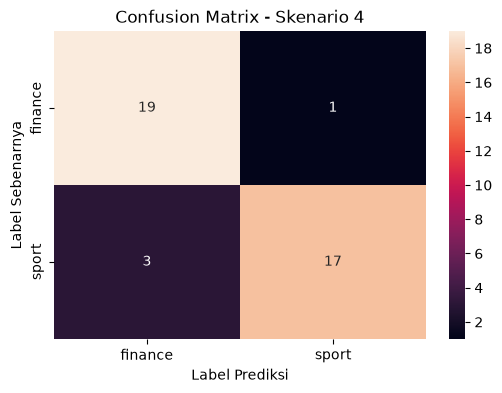

In [55]:
print("LAPORAN KLASIFIKASI SKENARIO 4:")

print(
    f"Akurasi Model : "
    f"{accuracy_score(y_test_s4, y_pred_s4) * 100:.2f}%\n"
)

print(
    classification_report(
        y_test_s4,
        y_pred_s4
    )
)

cm4 = confusion_matrix(
    y_test_s4,
    y_pred_s4
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm4,
    annot=True,
    fmt="d",
    xticklabels=nb_final_s4.classes_,
    yticklabels=nb_final_s4.classes_
)

plt.title("Confusion Matrix - Skenario 4")
plt.ylabel("Label Sebenarnya")
plt.xlabel("Label Prediksi")
plt.show()

# 22. Modeling Final Skenario 5

In [56]:
best_v5 = int(
    hasil_tuning_skenario_5[
        "Vector_Size"
    ].iloc[0]
)

best_w5 = int(
    hasil_tuning_skenario_5[
        "Window"
    ].iloc[0]
)

best_s5 = float(
    hasil_tuning_skenario_5[
        "Var_Smoothing"
    ].iloc[0]
)

print(
    "Menggunakan Parameter -> "
    f"Vector: {best_v5}, "
    f"Window: {best_w5}, "
    f"Smoothing: {best_s5}"
)

Menggunakan Parameter -> Vector: 75, Window: 3, Smoothing: 1e-09


In [57]:
model_w2v_final_s5 = latih_skipgram(
    df_all["token_skenario_5"],
    ukuran_vektor=best_v5,
    ukuran_window=best_w5
)

fitur_X_final_s5 = (
    df_all["token_skenario_5"]
    .apply(
        lambda x: get_vektor_rata_rata(
            x,
            model_w2v_final_s5
        )
    )
)

X_df_final_s5 = pd.DataFrame(
    fitur_X_final_s5.tolist()
)

y_df_final_s5 = df_all["kategori"]

In [58]:
X_train_s5, X_test_s5, y_train_s5, y_test_s5 = train_test_split(
    X_df_final_s5,
    y_df_final_s5,
    test_size=0.2,
    random_state=42,
    stratify=y_df_final_s5
)

nb_final_s5 = GaussianNB(
    var_smoothing=best_s5
)

nb_final_s5.fit(
    X_train_s5,
    y_train_s5
)

y_pred_s5 = nb_final_s5.predict(
    X_test_s5
)

LAPORAN KLASIFIKASI SKENARIO 5:
Akurasi Model : 85.00%

              precision    recall  f1-score   support

     finance       0.82      0.90      0.86        20
       sport       0.89      0.80      0.84        20

    accuracy                           0.85        40
   macro avg       0.85      0.85      0.85        40
weighted avg       0.85      0.85      0.85        40



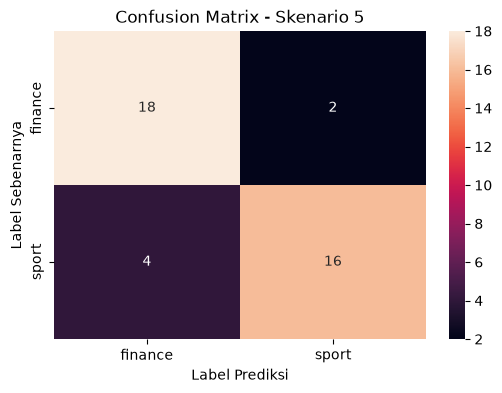

In [59]:
print("LAPORAN KLASIFIKASI SKENARIO 5:")

print(
    f"Akurasi Model : "
    f"{accuracy_score(y_test_s5, y_pred_s5) * 100:.2f}%\n"
)

print(
    classification_report(
        y_test_s5,
        y_pred_s5
    )
)

cm5 = confusion_matrix(
    y_test_s5,
    y_pred_s5
)

plt.figure(
    figsize=(6, 4)
)

sns.heatmap(
    cm5,
    annot=True,
    fmt="d",
    xticklabels=nb_final_s5.classes_,
    yticklabels=nb_final_s5.classes_
)

plt.title(
    "Confusion Matrix - Skenario 5"
)

plt.ylabel(
    "Label Sebenarnya"
)

plt.xlabel(
    "Label Prediksi"
)

plt.show()

# 23. Inspeksi Representasi Dokumen

Inspeksi dilakukan pada dokumen indeks 101.

Informasi yang ditampilkan:

- Kategori dokumen.
- Jumlah token.
- Sampel token.
- Shape vektor dokumen.
- Nilai representasi embedding dokumen.

Vektor dokumen diperoleh melalui mean pooling dari seluruh vektor kata
yang terdapat pada dokumen.

In [60]:
idx = 101

print(
    f"=== INFORMASI DOKUMEN KE-{idx} "
    f"(SKENARIO 1) ==="
)

print(
    f"Kategori : "
    f"{y_df_final_s1.iloc[idx]}"
)

print(
    f"Jumlah Token : "
    f"{len(df_all['token_skenario_1'].iloc[idx])} kata"
)

print(
    f"Sampel Token : "
    f"{df_all['token_skenario_1'].iloc[idx][:10]}..."
)

vektor_dokumen = (
    X_df_final_s1.iloc[idx].values
)

print(
    f"\nBentuk Vektor (Shape) : "
    f"{vektor_dokumen.shape}"
)

print(
    f"Representasi Vektor "
    f"({len(vektor_dokumen)} Dimensi):"
)

print(vektor_dokumen)

=== INFORMASI DOKUMEN KE-101 (SKENARIO 1) ===
Kategori : finance
Jumlah Token : 287 kata
Sampel Token : ['luas', 'akses', 'inklusi', 'uang', 'beri', 'solusi', 'biaya', 'jangkau', 'masyarakat', 'gadai']...

Bentuk Vektor (Shape) : (50,)
Representasi Vektor (50 Dimensi):
[ 0.08140966 -0.32120156 -0.15029392 -0.00720627 -0.12264979  0.14286779
  0.08909187  0.04667375 -0.24879782  0.3049441  -0.40997726  0.18110992
 -0.03144817  0.35850513  0.09308544 -0.14646216  0.19018878 -0.41139695
 -0.27013656  0.13888873 -0.08884113  0.19581972 -0.0593369   0.13039413
  0.2782052  -0.15205094 -0.16915654  0.02302753 -0.23864464 -0.20134759
  0.03201877  0.04807237 -0.06986702 -0.08581273 -0.19376989  0.07345452
  0.12508264 -0.704894    0.07080714  0.11554532 -0.29949164  0.1783363
  0.31566307 -0.05451316  0.18439929 -0.03821289  0.13087624  0.23709838
  0.38036093 -0.07291964]


In [61]:
print(
    f"=== INFORMASI DOKUMEN KE-{idx} "
    f"(SKENARIO 2) ==="
)

print(
    f"Kategori : "
    f"{y_df_final_s2.iloc[idx]}"
)

print(
    f"Jumlah Token : "
    f"{len(df_all['token_skenario_2'].iloc[idx])} kata"
)

print(
    f"Sampel Token : "
    f"{df_all['token_skenario_2'].iloc[idx][:10]}..."
)

vektor_dokumen = (
    X_df_final_s2.iloc[idx].values
)

print(
    f"\nBentuk Vektor (Shape) : "
    f"{vektor_dokumen.shape}"
)

print(
    f"Representasi Vektor "
    f"({len(vektor_dokumen)} Dimensi):"
)

print(vektor_dokumen)

=== INFORMASI DOKUMEN KE-101 (SKENARIO 2) ===
Kategori : finance
Jumlah Token : 318 kata
Sampel Token : ['luas', 'akses', 'inklusi', 'uang', 'beri', 'solusi', 'biaya', 'jangkau', 'masyarakat', 'gadai']...

Bentuk Vektor (Shape) : (50,)
Representasi Vektor (50 Dimensi):
[ 0.01296728 -0.74952376 -0.13207999  0.07682802 -0.2293543  -0.02865475
 -0.02323629  0.30718952 -0.2541974  -0.06205165 -0.16765921 -0.03373199
 -0.10955822  0.1503417  -0.03590128 -0.1980104   0.12314144 -0.07161668
 -0.1638278  -0.10874827  0.02946075 -0.00531421 -0.18758371  0.16207822
  0.21631126  0.20381771 -0.0953233   0.07798541 -0.28756297 -0.13209647
  0.1385505  -0.07179759 -0.02691534 -0.104412   -0.20134449 -0.21030095
 -0.23748401 -0.75794214 -0.09119084  0.41351444 -0.07633555  0.1272229
  0.5636471  -0.32418618  0.10103007  0.22845125  0.26547983  0.21412313
 -0.09077446 -0.29967067]


In [62]:
print(
    f"=== INFORMASI DOKUMEN KE-{idx} "
    f"(SKENARIO 3) ==="
)

print(
    f"Kategori : "
    f"{y_df_final_s3.iloc[idx]}"
)

print(
    f"Jumlah Token : "
    f"{len(df_all['token_skenario_3'].iloc[idx])} kata"
)

print(
    f"Sampel Token : "
    f"{df_all['token_skenario_3'].iloc[idx][:10]}..."
)

vektor_dokumen = (
    X_df_final_s3.iloc[idx].values
)

print(
    f"\nBentuk Vektor (Shape) : "
    f"{vektor_dokumen.shape}"
)

print(
    f"Representasi Vektor "
    f"({len(vektor_dokumen)} Dimensi):"
)

print(vektor_dokumen)

=== INFORMASI DOKUMEN KE-101 (SKENARIO 3) ===
Kategori : finance
Jumlah Token : 360 kata
Sampel Token : ['luas', 'akses', 'inklusi', 'uang', 'dan', 'beri', 'solusi', 'biaya', 'jangkau', 'bagi']...

Bentuk Vektor (Shape) : (100,)
Representasi Vektor (100 Dimensi):
[ 1.32910535e-01  1.30096320e-02 -2.75469068e-02  2.20119789e-01
 -1.59161374e-01  2.95457721e-01  5.78478873e-02  2.02705130e-01
  2.24799812e-02  3.13209035e-02 -2.53700197e-01  6.62321448e-02
  1.53177336e-01  1.35533646e-01 -2.52507743e-04  3.83633040e-02
  2.71194782e-02 -3.05002779e-01  8.35059658e-02  1.46729071e-02
  1.65037200e-01  2.70877391e-01  9.96220261e-02  1.48496464e-01
 -5.20213284e-02  1.83980092e-01 -3.49247098e-01  1.23799004e-01
 -4.84707505e-02 -1.67408779e-01  5.03145494e-02 -1.32387221e-01
  3.63083370e-02 -4.51094620e-02  4.92905043e-02 -1.08562194e-01
 -8.10430292e-03 -3.01595122e-01  1.45016126e-02  3.34263831e-01
  7.78602362e-02  1.02276884e-01  8.18765387e-02 -8.24746788e-02
  1.00652285e-01  2.1

In [63]:
print(
    f"=== INFORMASI DOKUMEN KE-{idx} "
    f"(SKENARIO 4) ==="
)

print(
    f"Kategori : "
    f"{y_df_final_s4.iloc[idx]}"
)

print(
    f"Jumlah Token : "
    f"{len(df_all['token_skenario_4'].iloc[idx])} kata"
)

print(
    f"Sampel Token : "
    f"{df_all['token_skenario_4'].iloc[idx][:10]}..."
)

vektor_dokumen = (
    X_df_final_s4.iloc[idx].values
)

print(
    f"\nBentuk Vektor (Shape) : "
    f"{vektor_dokumen.shape}"
)

print(
    f"Representasi Vektor "
    f"({len(vektor_dokumen)} Dimensi):"
)

print(vektor_dokumen)

=== INFORMASI DOKUMEN KE-101 (SKENARIO 4) ===
Kategori : finance
Jumlah Token : 287 kata
Sampel Token : ['perluas', 'akses', 'inklusi', 'keuangan', 'memberikan', 'solusi', 'pembiayaan', 'terjangkau', 'masyarakat', 'pegadaian']...

Bentuk Vektor (Shape) : (50,)
Representasi Vektor (50 Dimensi):
[-0.13676131 -0.3840299  -0.03794279  0.14679436  0.010492    0.11311165
  0.00886207  0.18086576 -0.11745809  0.11662742 -0.28945345  0.17522018
 -0.06118001  0.4166746   0.02724461 -0.10885494  0.1306607  -0.30564028
 -0.3915195  -0.01866912 -0.14028695  0.06953009 -0.16743076 -0.06512473
  0.25248584 -0.17838636 -0.00743954  0.09691191  0.06192804 -0.10008076
  0.11718304 -0.1174363  -0.14560093  0.07076558 -0.18767357 -0.13450436
  0.09235976 -0.43120888 -0.12569714  0.10078278 -0.06911606  0.3583877
  0.2513629  -0.2741349   0.12972338  0.06142329  0.13334827  0.1703128
  0.16500133 -0.09463879]


In [64]:
print(
    f"=== INFORMASI DOKUMEN KE-{idx} "
    f"(SKENARIO 5) ==="
)

print(
    f"Kategori : "
    f"{y_df_final_s5.iloc[idx]}"
)

print(
    f"Jumlah Token : "
    f"{len(df_all['token_skenario_5'].iloc[idx])} kata"
)

print(
    f"Sampel Token : "
    f"{df_all['token_skenario_5'].iloc[idx][:10]}..."
)

vektor_dokumen = (
    X_df_final_s5.iloc[idx].values
)

print(
    f"\nBentuk Vektor (Shape) : "
    f"{vektor_dokumen.shape}"
)

print(
    f"Representasi Vektor "
    f"({len(vektor_dokumen)} Dimensi):"
)

print(vektor_dokumen)

=== INFORMASI DOKUMEN KE-101 (SKENARIO 5) ===
Kategori : finance
Jumlah Token : 391 kata
Sampel Token : ['luas', 'akses', 'inklusi', 'uang', 'dan', 'beri', 'solusi', 'biaya', 'jangkau', 'bagi']...

Bentuk Vektor (Shape) : (75,)
Representasi Vektor (75 Dimensi):
[ 7.68914893e-02 -1.56840011e-01  7.41552785e-02 -1.29239261e-01
 -3.49926680e-01 -1.54657751e-01  4.39066738e-02  7.94944763e-02
 -2.21958935e-01  3.45316947e-01 -8.79433006e-02 -1.02565549e-01
 -1.36640683e-01  8.83279815e-02 -1.45747244e-01 -3.11187893e-01
  8.86762068e-02 -1.27433881e-01 -1.94864318e-01 -3.69226350e-03
  1.47699758e-01  1.74829602e-01  7.79759735e-02  2.77796984e-01
  1.01866320e-01  2.28355676e-01 -1.72774017e-01 -1.62558988e-01
 -1.24652982e-01  6.25551213e-03  3.37718844e-01 -3.22909117e-01
 -3.05937286e-02  1.30859405e-01 -2.29359210e-01  3.33730243e-02
 -2.80078277e-02 -3.85695010e-01  2.64110267e-01  1.25268817e-01
  3.51722178e-04  3.14876199e-01  1.71514645e-01 -5.10754921e-02
  2.18326524e-01 -1.193

# 24. Perbandingan Lima Skenario

Seluruh hasil hyperparameter tuning digabungkan untuk membandingkan
performa lima konfigurasi preprocessing.

Tabel akan diurutkan berdasarkan accuracy tertinggi.

In [65]:
hasil_tuning_skenario_1["Skenario"] = (
    "Skenario 1 (Tanpa Angka)"
)

hasil_tuning_skenario_2["Skenario"] = (
    "Skenario 2 (Dengan Angka)"
)

hasil_tuning_skenario_3["Skenario"] = (
    "Skenario 3 (Tanpa Stopword)"
)

hasil_tuning_skenario_4["Skenario"] = (
    "Skenario 4 (Tanpa Stemming)"
)

hasil_tuning_skenario_5["Skenario"] = (
    "Skenario 5 (Dengan Stopword dan Angka)"
)

df_komparasi = pd.concat(
    [
        hasil_tuning_skenario_1,
        hasil_tuning_skenario_2,
        hasil_tuning_skenario_3,
        hasil_tuning_skenario_4,
        hasil_tuning_skenario_5
    ],
    ignore_index=True
)

df_komparasi = df_komparasi[
    [
        "Skenario",
        "Vector_Size",
        "Window",
        "Var_Smoothing",
        "Akurasi"
    ]
]

df_komparasi_terurut = (
    df_komparasi
    .sort_values(
        by="Akurasi",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "=== KOMPARASI KESELURUHAN LIMA SKENARIO ==="
)

display(
    df_komparasi_terurut.head(10)
)

=== KOMPARASI KESELURUHAN LIMA SKENARIO ===


,Skenario,Vector_Size,Window,Var_Smoothing,Akurasi
0,Skenario 2 (Dengan Angka),100,7,1.000000e-09,0.925
1,Skenario 2 (Dengan Angka),100,7,1.000000e-05,0.925
2,Skenario 2 (Dengan Angka),75,7,1.000000e-05,0.925
3,Skenario 2 (Dengan Angka),75,7,1.000000e-09,0.925
4,Skenario 2 (Dengan Angka),50,7,1.000000e-09,0.925
5,Skenario 2 (Dengan Angka),50,7,1.000000e-05,0.925
6,Skenario 1 (Tanpa Angka),50,3,1.000000e-09,0.900
7,Skenario 1 (Tanpa Angka),50,7,1.000000e-05,0.900
8,Skenario 1 (Tanpa Angka),50,7,1.000000e-09,0.900
9,Skenario 1 (Tanpa Angka),50,5,1.000000e-05,0.900


In [66]:
print("=== AKURASI TERTINGGI SETIAP SKENARIO ===")

akurasi_terbaik = (
    df_komparasi
    .groupby("Skenario")["Akurasi"]
    .max()
    .sort_values(
        ascending=False
    )
)

display(
    akurasi_terbaik
)

=== AKURASI TERTINGGI SETIAP SKENARIO ===


Skenario
Skenario 2 (Dengan Angka)                 0.925
Skenario 1 (Tanpa Angka)                  0.900
Skenario 3 (Tanpa Stopword)               0.900
Skenario 4 (Tanpa Stemming)               0.900
Skenario 5 (Dengan Stopword dan Angka)    0.875
Name: Akurasi, dtype: float64

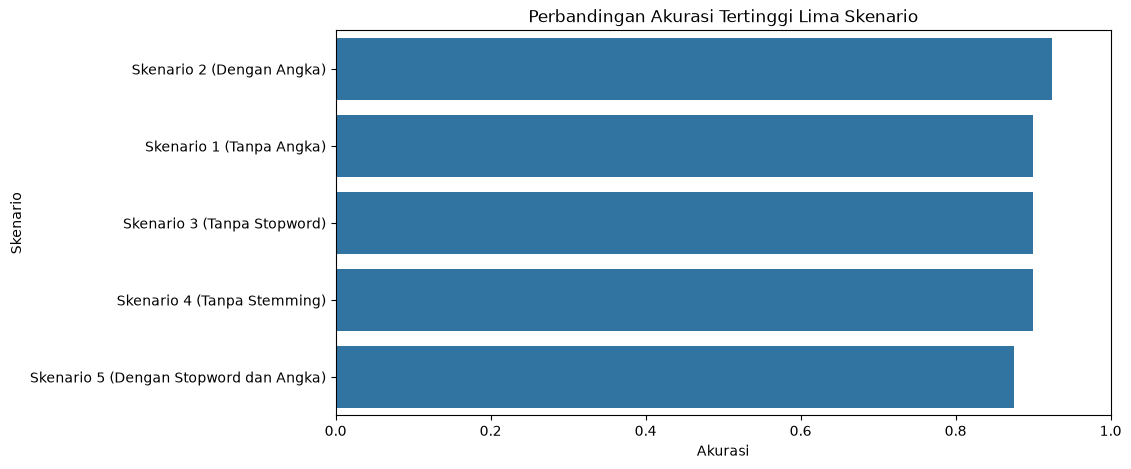

In [67]:
plt.figure(
    figsize=(10, 5)
)

sns.barplot(
    x=akurasi_terbaik.values,
    y=akurasi_terbaik.index
)

plt.xlabel("Akurasi")
plt.ylabel("Skenario")
plt.title(
    "Perbandingan Akurasi Tertinggi Lima Skenario"
)

plt.xlim(
    0,
    1
)

plt.show()

# 25. Konfigurasi Terbaik

Konfigurasi terbaik ditentukan berdasarkan accuracy tertinggi dari tabel
hasil tuning.

Selain accuracy, hasil evaluasi final juga perlu mempertimbangkan:

- Precision
- Recall
- F1-score
- Confusion matrix

Oleh karena itu, accuracy digunakan untuk menentukan kandidat konfigurasi
terbaik dari tuning, sedangkan performa kelas diperiksa melalui laporan
evaluasi model final.

In [68]:
baris_terbaik = (
    df_komparasi_terurut.iloc[0]
)

print("=== KONFIGURASI TERBAIK DARI HASIL TUNING ===")

print(
    f"Skenario       : "
    f"{baris_terbaik['Skenario']}"
)

print(
    f"Vector Size    : "
    f"{int(baris_terbaik['Vector_Size'])}"
)

print(
    f"Window         : "
    f"{int(baris_terbaik['Window'])}"
)

print(
    f"Var Smoothing  : "
    f"{baris_terbaik['Var_Smoothing']}"
)

print(
    f"Akurasi        : "
    f"{baris_terbaik['Akurasi'] * 100:.2f}%"
)

=== KONFIGURASI TERBAIK DARI HASIL TUNING ===
Skenario       : Skenario 2 (Dengan Angka)
Vector Size    : 100
Window         : 7
Var Smoothing  : 1e-09
Akurasi        : 92.50%


# 26. Ekspor Model

Model dapat disimpan agar dapat digunakan kembali tanpa melakukan training
ulang.

File yang disimpan:

- Model Word2Vec lengkap.
- KeyedVectors Word2Vec.
- Model Gaussian Naive Bayes.

Pada contoh ini digunakan Skenario 1.

In [69]:
pilihan_skenario = 1

if pilihan_skenario == 1:

    print(
        "\nMenyimpan model dari Skenario 1..."
    )

    model_w2v_final_s1.save(
        "w2v_skenario1_final.model"
    )

    model_w2v_final_s1.wv.save(
        "w2v_skenario1_vectors.kv"
    )

    joblib.dump(
        nb_final_s1,
        "naive_bayes_skenario1.pkl"
    )

    print(
        "Berhasil! Model Skip-gram dan "
        "Naive Bayes Skenario 1 telah disimpan."
    )

elif pilihan_skenario == 2:

    print(
        "\nMenyimpan model dari Skenario 2..."
    )

    model_w2v_final_s2.save(
        "w2v_skenario2_final.model"
    )

    joblib.dump(
        nb_final_s2,
        "naive_bayes_skenario2.pkl"
    )

    print(
        "Berhasil! Model Skip-gram dan "
        "Naive Bayes Skenario 2 telah disimpan."
    )

else:

    print(
        "\nPilihan tidak valid. "
        "Masukkan angka 1 atau 2."
    )


Menyimpan model dari Skenario 1...
Berhasil! Model Skip-gram dan Naive Bayes Skenario 1 telah disimpan.


In [70]:
import os

file_model = [
    "w2v_skenario1_final.model",
    "w2v_skenario1_vectors.kv",
    "naive_bayes_skenario1.pkl"
]

print("=== FILE MODEL YANG BERHASIL DISIMPAN ===")

for file in file_model:
    if os.path.exists(file):
        print(
            f"{file} -> tersedia"
        )
    else:
        print(
            f"{file} -> tidak ditemukan"
        )

=== FILE MODEL YANG BERHASIL DISIMPAN ===
w2v_skenario1_final.model -> tersedia
w2v_skenario1_vectors.kv -> tersedia
naive_bayes_skenario1.pkl -> tersedia


# 27. Kesimpulan

Berdasarkan eksperimen yang telah dilakukan, Word2Vec digunakan untuk
mengubah representasi kata pada berita bahasa Indonesia menjadi vektor
numerik.

Arsitektur yang digunakan adalah **Skip-gram**. Representasi kata kemudian
dirata-ratakan menggunakan **mean pooling** sehingga setiap dokumen memiliki
vektor dengan dimensi tetap.

Eksperimen dilakukan menggunakan lima skenario preprocessing yang berbeda,
yaitu:

1. Menghapus angka, stopword, dan menggunakan stemming.
2. Mempertahankan angka, menghapus stopword, dan menggunakan stemming.
3. Menghapus angka, mempertahankan stopword, dan menggunakan stemming.
4. Menghapus angka dan stopword tanpa stemming.
5. Mempertahankan angka dan stopword serta menggunakan stemming.

Setiap skenario diuji menggunakan kombinasi:

- `vector_size = [50, 75, 100]`
- `window = [3, 5, 7]`
- `var_smoothing = [1e-9, 1e-5, 1e-1]`

Dengan demikian terdapat 27 kombinasi untuk setiap skenario.

Hasil tuning kemudian digunakan untuk membentuk model final menggunakan
Gaussian Naive Bayes. Evaluasi dilakukan menggunakan accuracy,
precision, recall, F1-score, dan confusion matrix.

Konfigurasi terbaik ditentukan berdasarkan hasil eksperimen aktual pada
tabel komparasi lima skenario.

## Catatan Metodologis

Eksperimen ini mengikuti alur pada referensi Fauzan, termasuk proses
pelatihan Word2Vec sebelum pembagian train-test.

Pendekatan tersebut memiliki keterbatasan karena embedding dibentuk dari
seluruh korpus sebelum data dibagi menjadi data latih dan data uji.
Akibatnya, data uji ikut berkontribusi terhadap pembentukan vocabulary dan
embedding.

Untuk penelitian yang lebih ketat, data dapat dipisahkan terlebih dahulu,
kemudian Word2Vec hanya dilatih menggunakan data training. Proses tuning
juga dapat menggunakan validation set atau cross-validation, sedangkan
test set akhir hanya digunakan setelah pemilihan model selesai.

Mean pooling juga menghilangkan informasi urutan kata. Selain itu,
penggunaan `min_count=1` memungkinkan kata yang sangat jarang masuk ke
vocabulary sehingga representasinya dapat kurang stabil pada korpus yang
terbatas.

In [71]:
import joblib

pilihan_skenario = 1

if pilihan_skenario == 1:

    print("Menyimpan model dari Skenario 1...")

    model_w2v_final_s1.save(
        "w2v_skenario1_final.model"
    )

    model_w2v_final_s1.wv.save(
        "w2v_skenario1_vectors.kv"
    )

    joblib.dump(
        nb_final_s1,
        "naive_bayes_skenario1.pkl"
    )

    print(
        "Berhasil! Model Skip-gram dan "
        "Naive Bayes Skenario 1 telah disimpan."
    )

elif pilihan_skenario == 2:

    print("Menyimpan model dari Skenario 2...")

    model_w2v_final_s2.save(
        "w2v_skenario2_final.model"
    )

    joblib.dump(
        nb_final_s2,
        "naive_bayes_skenario2.pkl"
    )

    print(
        "Berhasil! Model Skip-gram dan "
        "Naive Bayes Skenario 2 telah disimpan."
    )

else:

    print(
        "Pilihan tidak valid. "
        "Masukkan angka 1 atau 2."
    )

Menyimpan model dari Skenario 1...
Berhasil! Model Skip-gram dan Naive Bayes Skenario 1 telah disimpan.


In [72]:
import joblib

model_w2v_final_s1.save(
    "w2v_skenario1_final.model"
)

joblib.dump(
    nb_final_s1,
    "naive_bayes_skenario1.pkl"
)

print("Model Skenario 1 berhasil diekspor.")

Model Skenario 1 berhasil diekspor.


In [ ]:
### link app klasifikasi berita

https://ppw-klasifikasi-berita-detikcom.streamlit.app/

